<a href="https://colab.research.google.com/github/kuroushi/Factors_influencing_US-home_prices/blob/main/Factors_influencing_house_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the Files

In [2]:
files = ['GDPC1.csv', 'MEHOINUSA672N.csv', 'MORTGAGE30US.csv', 'TTLHH.csv','CPIAUCSL.csv','FEDFUNDS.csv',
         'MSACSR.csv','PAYEMS.csv','UNRATE.csv','CSUSHPISA.csv']
dataframes = [pd.read_csv(f) for f in files]


Real_gross_domestic_product = dataframes[0]
Household_income = dataframes[1]
Mortgage_rate = dataframes[2]
Total_households = dataframes[3]
Consumer_price_index= dataframes[4]
Federal_funds_effextive_rate= dataframes[5]
Supply_of_new_houses= dataframes[6]
Total_nonfarm_payroll= dataframes[7]
Unemployment_rate= dataframes[8]
House_price_index= dataframes[9]

In [3]:
# Function to convert data monthly with interpolation
def convert_to_monthly(file_path, value_column):
    df = pd.read_csv(file_path)
    df['observation_date'] = pd.to_datetime(df['observation_date'])
    df.set_index('observation_date', inplace=True)
    monthly_df = df.resample('MS').interpolate(method='linear')
    return monthly_df[[value_column]]

# Process multiple files
Real_gross_domestic_product = convert_to_monthly('GDPC1.csv', 'GDPC1')
Household_income = convert_to_monthly('MEHOINUSA672N.csv', 'MEHOINUSA672N')
Total_households = convert_to_monthly('TTLHH.csv', 'TTLHH')
Consumer_price_index= convert_to_monthly('CPIAUCSL.csv', 'CPIAUCSL')
Federal_funds_effextive_rate= convert_to_monthly('FEDFUNDS.csv', 'FEDFUNDS')
Supply_of_new_houses= convert_to_monthly('MSACSR.csv', 'MSACSR')
Total_nonfarm_payroll= convert_to_monthly('PAYEMS.csv', 'PAYEMS')
Unemployment_rate= convert_to_monthly('UNRATE.csv', 'UNRATE')
House_price_index= convert_to_monthly('CSUSHPISA.csv', 'CSUSHPISA')

In [4]:
Mortgage_rate['observation_date'] = pd.to_datetime(Mortgage_rate['observation_date'])
Mortgage_rate.set_index('observation_date', inplace=True)

# Resample weekly data to monthly using mean
Mortgage_rate = Mortgage_rate.resample('MS').mean()
Mortgage_rate = Mortgage_rate.rename(columns={'MORTGAGE30US': 'Mortgage_rate'})
Mortgage_rate.head()

,Mortgage_rate
observation_date,
2000-01-01,8.2100
2000-02-01,8.3250
2000-03-01,8.2400
2000-04-01,8.1525
2000-05-01,8.5150


In [5]:
# Combine all into a single DataFrame (optional)
combined_df = pd.concat([Real_gross_domestic_product, Household_income,Mortgage_rate,Total_households, Consumer_price_index ,
                        Federal_funds_effextive_rate, Supply_of_new_houses,Total_nonfarm_payroll,Unemployment_rate,House_price_index], axis=1)

# View the result
combined_df.head()

,GDPC1,MEHOINUSA672N,Mortgage_rate,TTLHH,CPIAUCSL,FEDFUNDS,MSACSR,PAYEMS,UNRATE,CSUSHPISA
observation_date,,,,,,,,,,
2000-01-01,13878.147000,70020.000000,8.2100,104705.0,169.3,5.45,4.3,131011,4.0,100.552
2000-02-01,13962.400667,69924.166667,8.3250,104997.0,170.0,5.73,4.3,131121,4.1,101.339
2000-03-01,14046.654333,69828.333333,8.2400,105289.0,171.0,5.85,4.3,131604,4.0,102.127
2000-04-01,14130.908000,69732.500000,8.1525,105581.0,170.9,6.02,4.4,131883,3.8,102.923
2000-05-01,14135.709333,69636.666667,8.5150,105873.0,171.2,6.27,4.4,132105,4.0,103.678


In [6]:

# Rename columns to dataframe names
combined_df = combined_df.rename(columns={
    'GDPC1': 'Real_gross_domestic_product',
    'MEHOINUSA672N': 'Household_income',
    'Mortgage_rate': 'Mortgage_rate',
    'TTLHH': 'Total_households',
    'CPIAUCSL': 'Consumer_price_index',
    'FEDFUNDS': 'Federal_funds_effextive_rate',
    'MSACSR': 'Supply_of_new_houses',
    'PAYEMS': 'Total_nonfarm_payroll',
    'UNRATE': 'Unemployment_rate',
    'CSUSHPISA': 'House_price_index'
})

# View the result
combined_df.head()


,Real_gross_domestic_product,Household_income,Mortgage_rate,Total_households,Consumer_price_index,Federal_funds_effextive_rate,Supply_of_new_houses,Total_nonfarm_payroll,Unemployment_rate,House_price_index
observation_date,,,,,,,,,,
2000-01-01,13878.147000,70020.000000,8.2100,104705.0,169.3,5.45,4.3,131011,4.0,100.552
2000-02-01,13962.400667,69924.166667,8.3250,104997.0,170.0,5.73,4.3,131121,4.1,101.339
2000-03-01,14046.654333,69828.333333,8.2400,105289.0,171.0,5.85,4.3,131604,4.0,102.127
2000-04-01,14130.908000,69732.500000,8.1525,105581.0,170.9,6.02,4.4,131883,3.8,102.923
2000-05-01,14135.709333,69636.666667,8.5150,105873.0,171.2,6.27,4.4,132105,4.0,103.678


In [7]:
combined_df.shape

(301, 10)

#Finding Missing Values

In [8]:
## Here we will check the percentage of nan values present in each feature
## 1 -step make the list of features which has missing values
features_with_na=[features for features in combined_df.columns if combined_df[features].isnull().sum()>1]
## 2- step print the feature name and the percentage of missing values

for feature in features_with_na:
    print(feature, np.round(combined_df[feature].isnull().mean(), 4),  ' % missing values')

Real_gross_domestic_product 0.01  % missing values
Household_income 0.0797  % missing values
Total_households 0.0399  % missing values


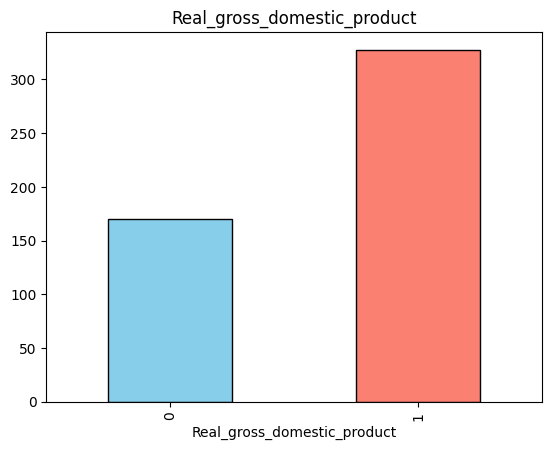

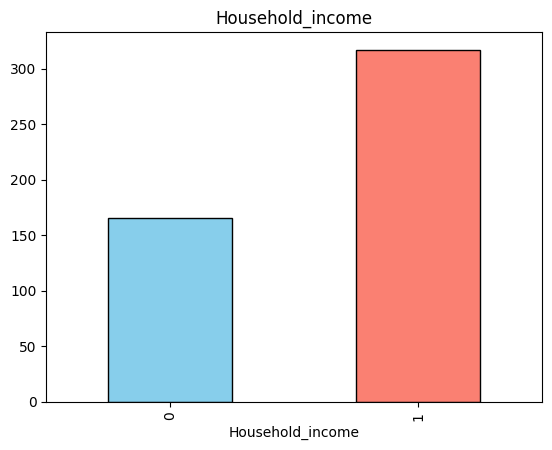

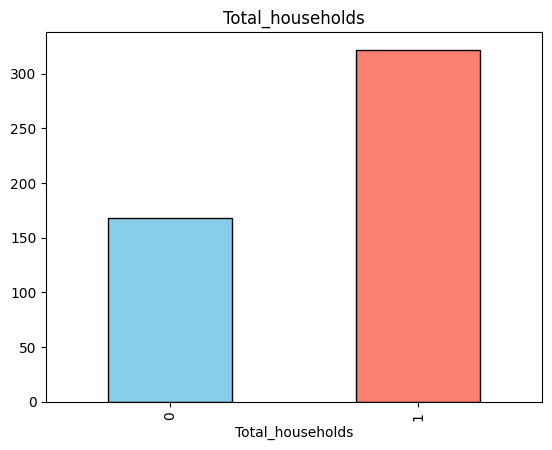

In [9]:
for feature in features_with_na:
    data = combined_df.copy()

    # let's make a variable that indicates 1 if the observation was missing or zero otherwise
    data[feature] = np.where(data[feature].isnull(), 1, 0)

    # let's calculate the mean SalePrice where the information is missing or present
    grouped_data=data.groupby(feature)['House_price_index'].median()
    grouped_data.plot.bar(color=['skyblue', 'salmon'], edgecolor='black')
    plt.title(feature)
    plt.show()

#Outliers


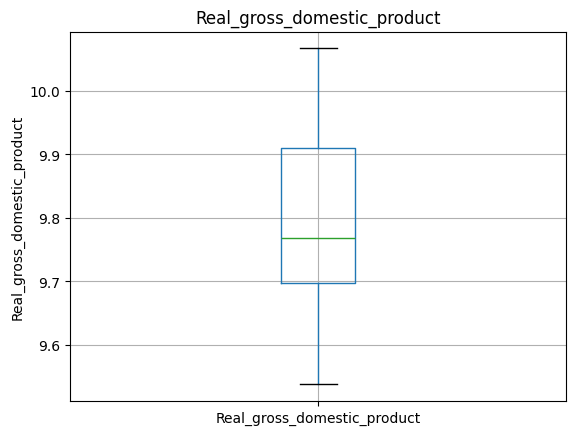

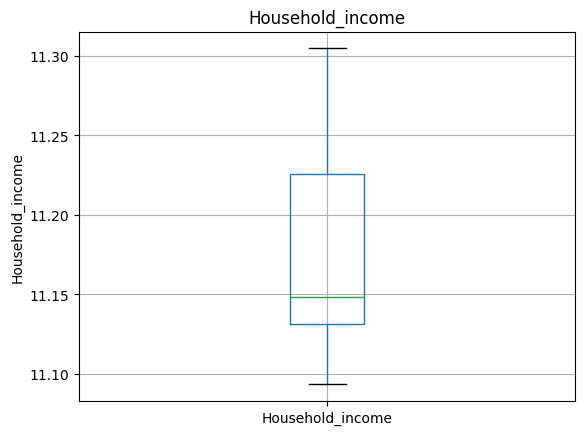

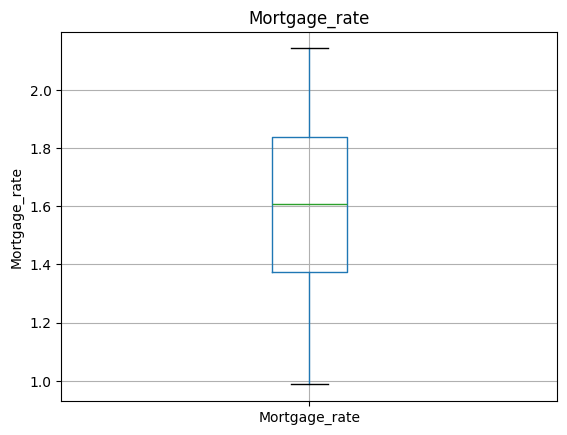

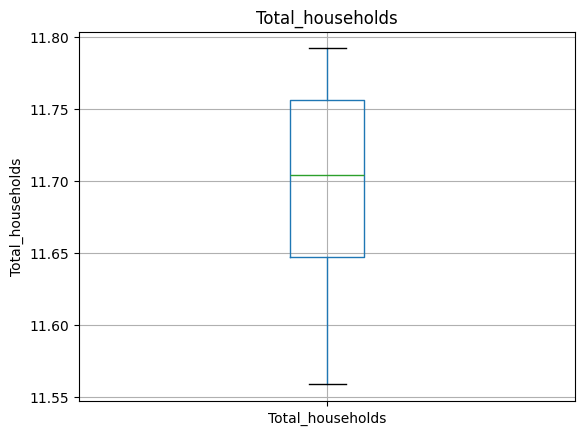

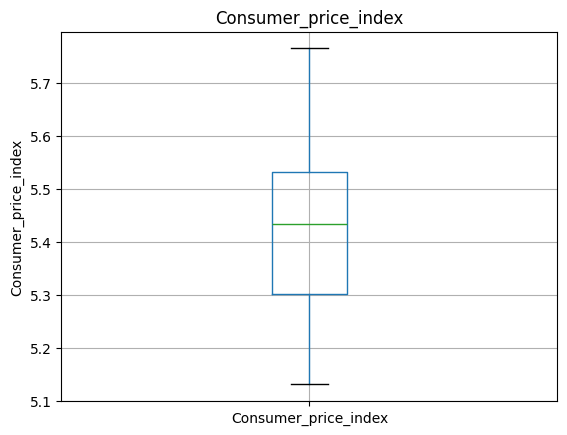

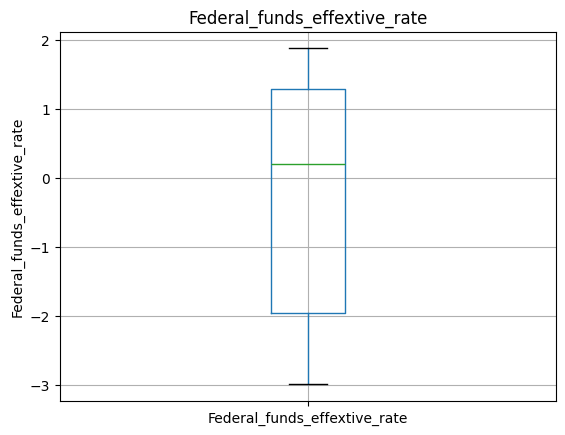

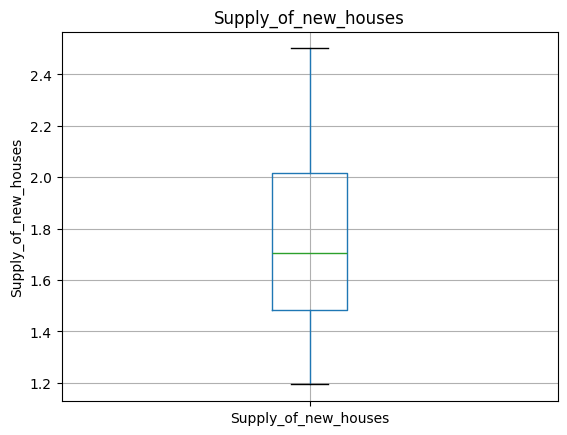

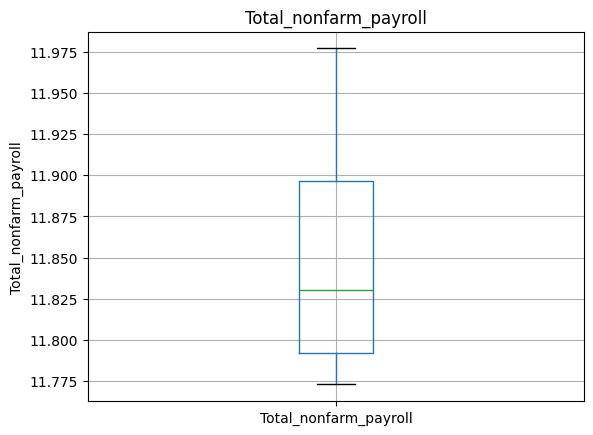

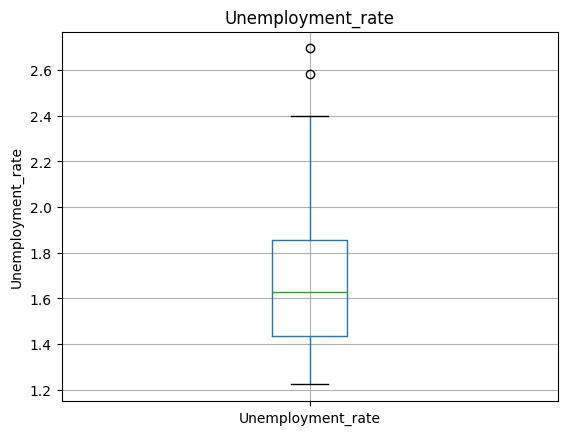

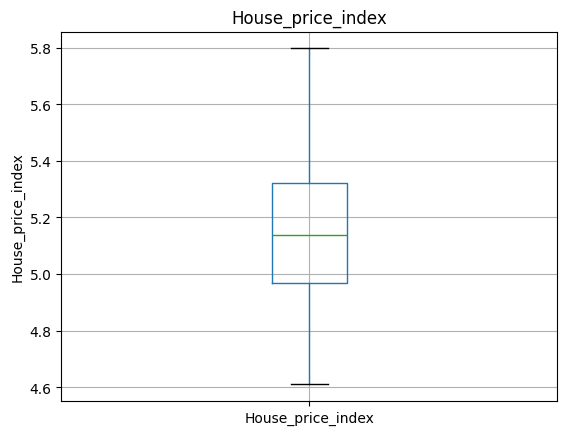

In [10]:
feature_distribution =[col for col in combined_df.columns if col != 'observation_date']
for feature in feature_distribution:
    data=combined_df.copy()
    if 0 in data[feature].unique():
        pass
    else:
        data[feature]=np.log(data[feature])
        data.boxplot(column=feature)
        plt.ylabel(feature)
        plt.title(feature)
        plt.show()

#Replacing Nan Values

In [11]:
for feature in features_with_na:
    ## We will replace by using median since there are outliers
    median_value=combined_df[feature].median()

    ## create a new feature to capture nan values
    combined_df[feature+'nan']=np.where(combined_df[feature].isnull(),1,0)
    combined_df[feature].fillna(median_value,inplace=True)

combined_df[features_with_na].isnull().sum()


<ipython-input-11-d6059821d763>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df[feature].fillna(median_value,inplace=True)
<ipython-input-11-d6059821d763>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,0
Real_gross_domestic_product,0
Household_income,0
Total_households,0


In [12]:
combined_df.tail(10)

,Real_gross_domestic_product,Household_income,Mortgage_rate,Total_households,Consumer_price_index,Federal_funds_effextive_rate,Supply_of_new_houses,Total_nonfarm_payroll,Unemployment_rate,House_price_index,Real_gross_domestic_productnan,Household_incomenan,Total_householdsnan
observation_date,,,,,,,,,,,,,
2024-04-01,23223.906000,69445.0,6.9925,121084.0,313.016,5.33,7.6,157635,3.9,319.325,0,1,1
2024-05-01,23282.702000,69445.0,7.0600,121084.0,313.140,5.33,8.4,157828,4.0,320.086,0,1,1
2024-06-01,23341.498000,69445.0,6.9175,121084.0,313.131,5.33,8.4,157915,4.1,320.542,0,1,1
2024-07-01,23400.294000,69445.0,6.8475,121084.0,313.566,5.33,7.9,158003,4.2,321.227,0,1,1
2024-08-01,23447.645667,69445.0,6.5000,121084.0,314.131,5.33,8.2,158074,4.2,322.299,0,1,1
2024-09-01,23494.997333,69445.0,6.1800,121084.0,314.851,5.13,7.8,158314,4.1,323.311,0,1,1
2024-10-01,23542.349000,69445.0,6.4280,121084.0,315.564,4.83,9.2,158358,4.1,324.491,0,1,1
2024-11-01,17457.087500,69445.0,6.8050,121084.0,316.449,4.64,8.6,158619,4.2,326.013,1,1,1
2024-12-01,17457.087500,69445.0,6.7150,121084.0,317.603,4.48,8.2,158942,4.1,327.582,1,1,1


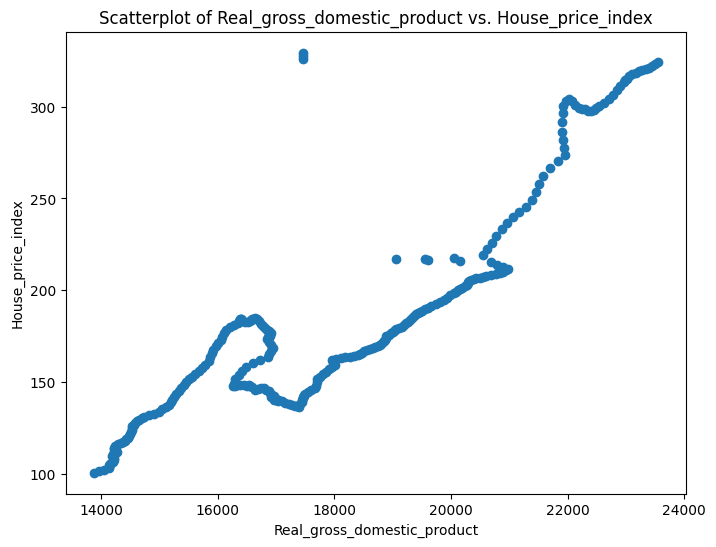

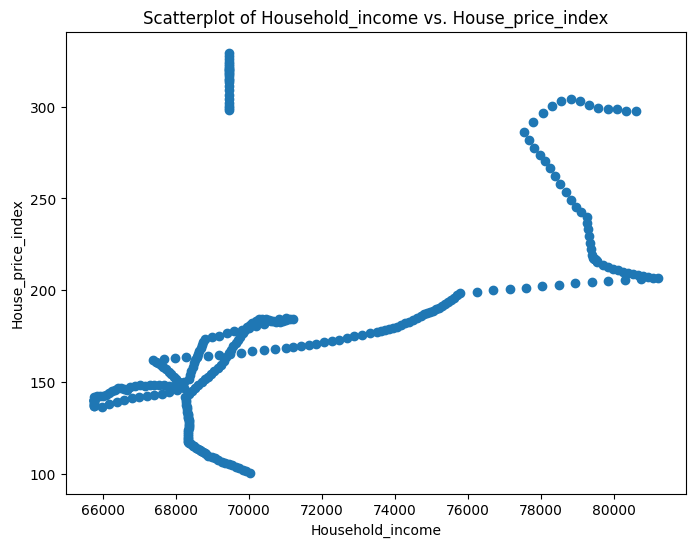

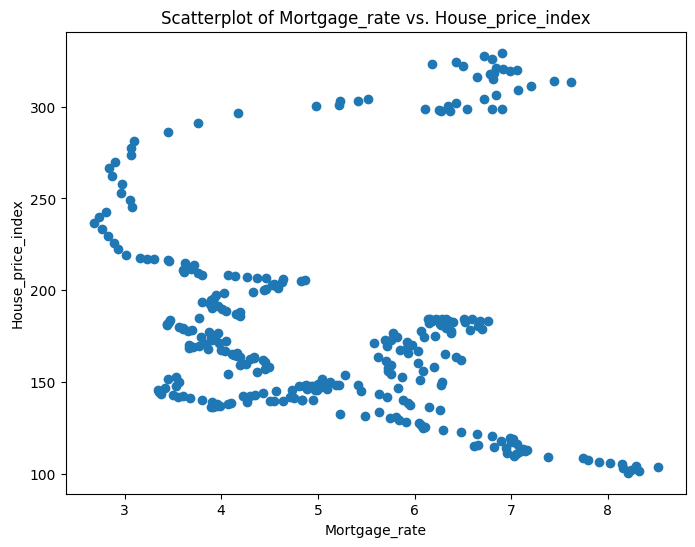

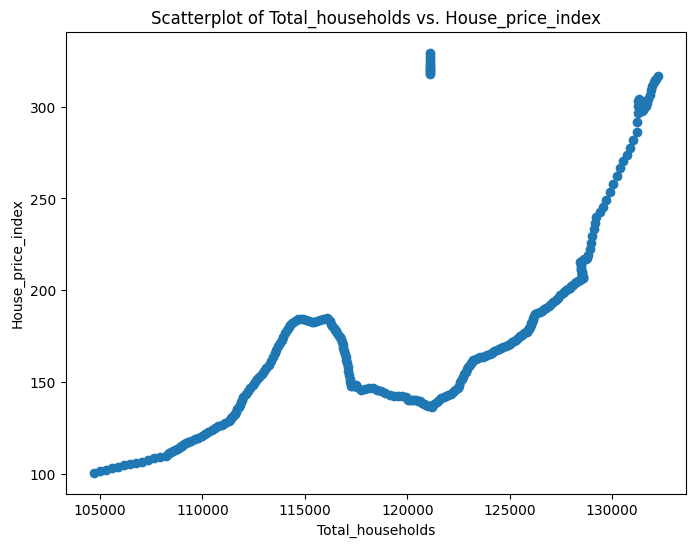

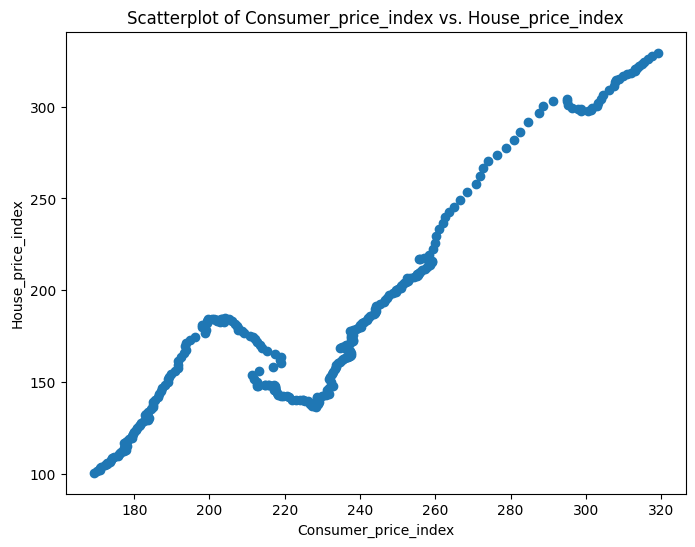

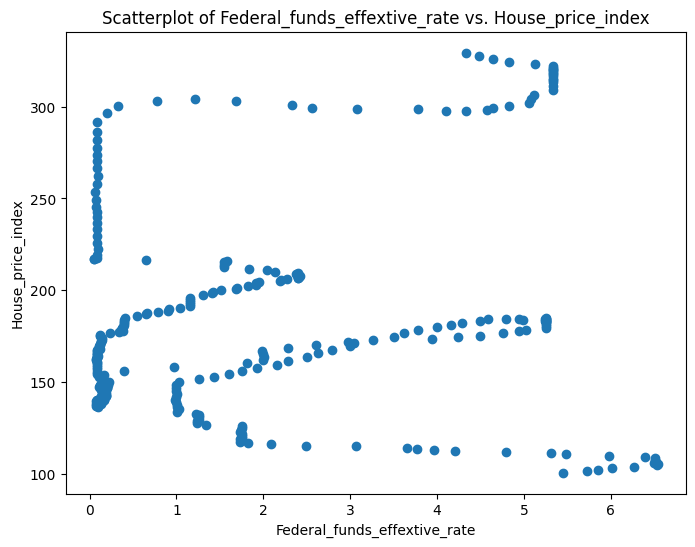

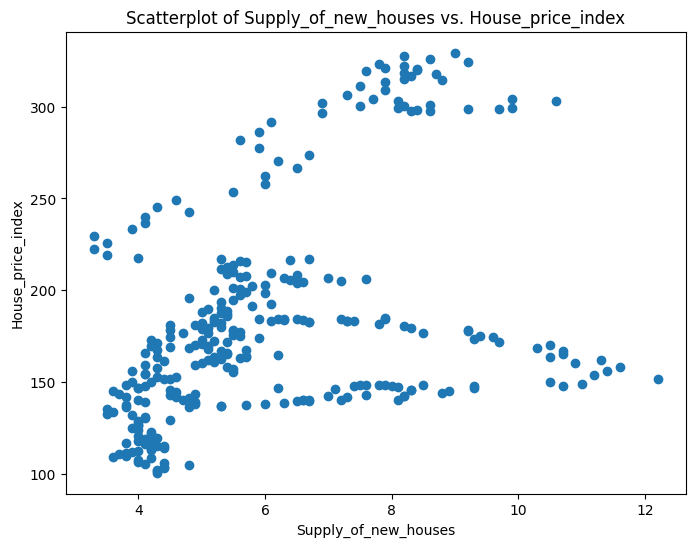

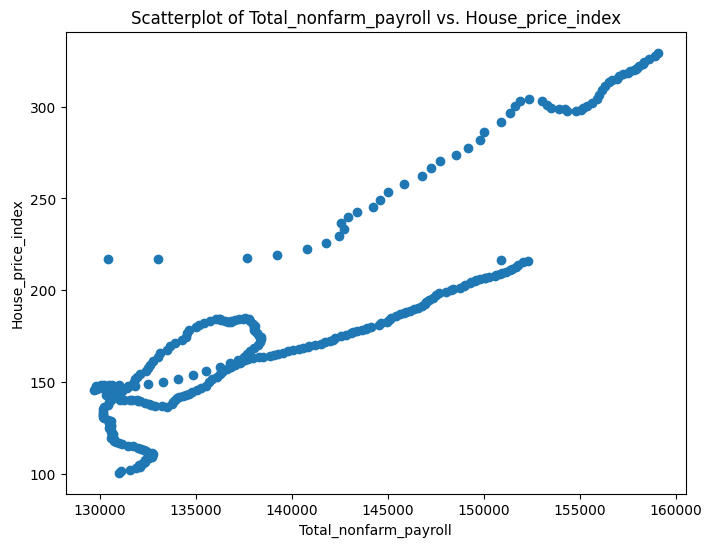

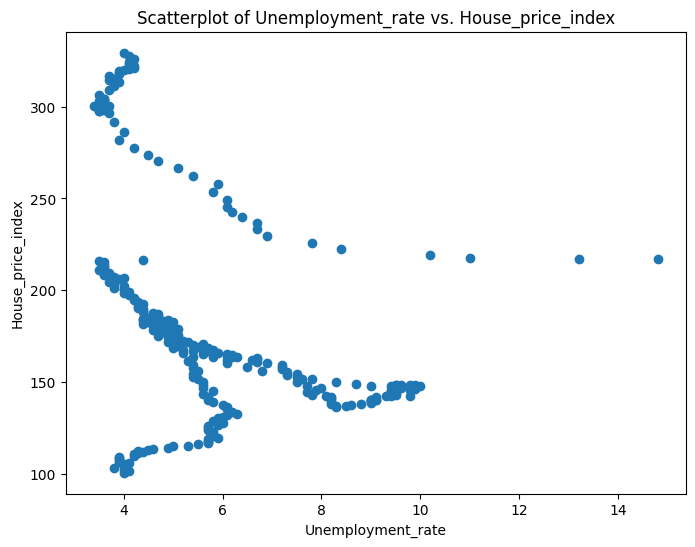

In [13]:
# prompt: show all the columns except 'Real_gross_domestic_productnan','Household_incomenan','Total_householdsnan' against house_price_index in a scatterplot

# Assuming 'combined_df' is already defined as in the provided code.

exclude_column = ['Real_gross_domestic_productnan', 'Household_incomenan', 'Total_householdsnan']
plot_columns = [col for col in combined_df.columns if col not in exclude_column and col != 'House_price_index' and col != 'observation_date']


for col in plot_columns:
  plt.figure(figsize=(8, 6))
  plt.scatter(combined_df[col], combined_df['House_price_index'])
  plt.xlabel(col)
  plt.ylabel('House_price_index')
  plt.title(f'Scatterplot of {col} vs. House_price_index')
  plt.show()


In [14]:
combined_df.head()

,Real_gross_domestic_product,Household_income,Mortgage_rate,Total_households,Consumer_price_index,Federal_funds_effextive_rate,Supply_of_new_houses,Total_nonfarm_payroll,Unemployment_rate,House_price_index,Real_gross_domestic_productnan,Household_incomenan,Total_householdsnan
observation_date,,,,,,,,,,,,,
2000-01-01,13878.147000,70020.000000,8.2100,104705.0,169.3,5.45,4.3,131011,4.0,100.552,0,0,0
2000-02-01,13962.400667,69924.166667,8.3250,104997.0,170.0,5.73,4.3,131121,4.1,101.339,0,0,0
2000-03-01,14046.654333,69828.333333,8.2400,105289.0,171.0,5.85,4.3,131604,4.0,102.127,0,0,0
2000-04-01,14130.908000,69732.500000,8.1525,105581.0,170.9,6.02,4.4,131883,3.8,102.923,0,0,0
2000-05-01,14135.709333,69636.666667,8.5150,105873.0,171.2,6.27,4.4,132105,4.0,103.678,0,0,0


#Model Building

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = combined_df.drop(['House_price_index','Real_gross_domestic_productnan','Household_incomenan','Total_householdsnan'], axis=1) # Features (exclude target and date)
y = combined_df['House_price_index']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 228.97974924524172


In [16]:
print(model.score(X_train,y_train))

0.9388583042908698


In [17]:
print(model.score(X_test,y_test))

0.9383614401452485


                   Actual   Predicted
observation_date                     
2014-10-01        166.634  180.671093
2024-02-01        317.648  329.599427
2019-01-01        206.535  219.465082
2016-07-01        180.842  179.072461
2005-01-01        161.289  139.115801
...                   ...         ...
2019-07-01        209.175  222.014664
2024-09-01        323.311  328.564683
2023-06-01        304.028  288.566659
2023-10-01        313.259  292.307565
2015-03-01        169.789  176.944361

[61 rows x 2 columns]


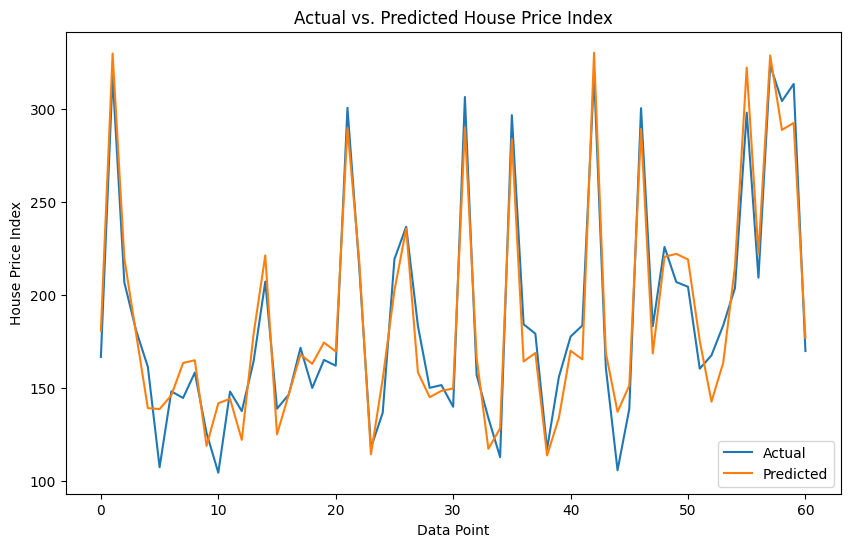

In [18]:
# Compare predictions with actual values
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df)

# You can also visualize the comparison
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.xlabel('Data Point')
plt.ylabel('House Price Index')
plt.title('Actual vs. Predicted House Price Index')
plt.legend()
plt.show()